# Blending Data from Multiple Sources

This is an example showing how to merge multiple data sources. 

In [1]:
import pyearthtools.data
import tempfile

import warnings
warnings.filterwarnings('ignore')

import site_archive_nci

In [2]:
doi = '2021-01-01T0100'

In [21]:
himawari = pyearthtools.data.archive.Himawari('surface_global_irradiance')

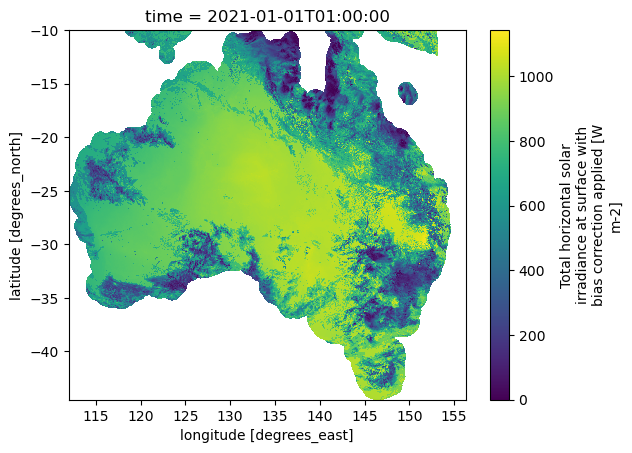

In [22]:
sample_sgi = himawari[doi].surface_global_irradiance
sample_sgi.plot()

In [23]:
sample_sgi

<xarray.DataArray 'surface_global_irradiance' (time: 1, latitude: 1726,
                                               longitude: 2214)> Size: 31MB
dask.array<broadcast_to, shape=(1, 1726, 2214), dtype=float64, chunksize=(1, 1726, 2214), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 8B 2021-01-01T01:00:00
  * latitude   (latitude) float32 7kB -44.5 -44.48 -44.46 ... -10.02 -10.0
  * longitude  (longitude) float32 9kB 112.0 112.0 112.0 ... 156.2 156.2 156.3
Attributes:
    standard_name:  surface_downwelling_shortwave_flux_in_air
    long_name:      Total horizontal solar irradiance at surface with bias co...
    comment:        Bias correction has been applied. Surface downwelling sho...
    units:          W m-2
    valid_min:      0
    valid_max:      140000
    grid_mapping:   crs

In [24]:
like_himawari = pyearthtools.data.transform.region.like(sample_sgi) # Make things like the Himawari region
access_g = pyearthtools.data.archive.ACCESS( variables='sfc/mslp', datatype='an', region='g',transforms=like_himawari)
sample_mslp = access_g[doi].mslp

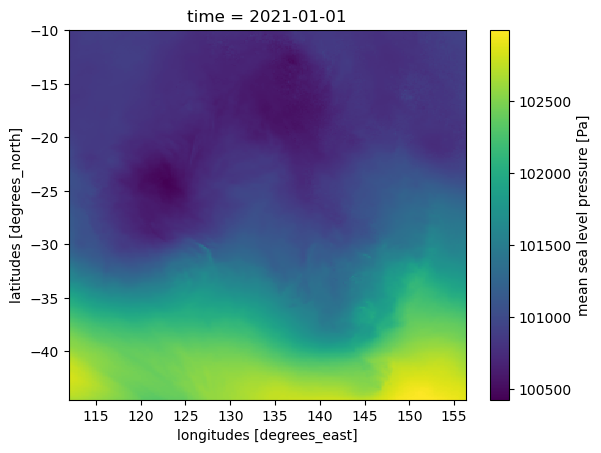

In [25]:
sample_mslp.plot()

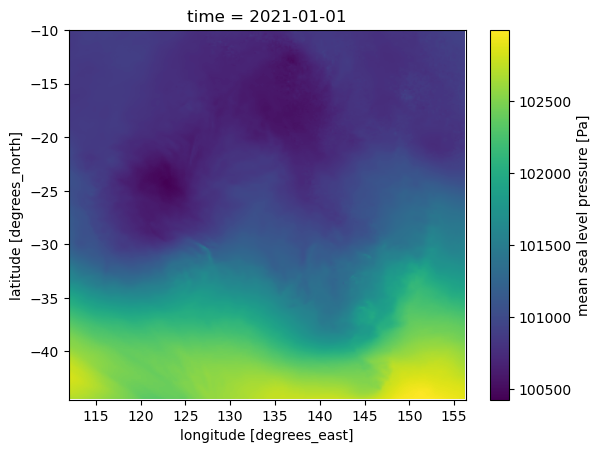

In [26]:
sample_mslp[0].interp_like(sample_sgi[0]).plot()

In [27]:
import pyearthtools.pipeline as petpipe

In [39]:
pipe = petpipe.Pipeline(
    (himawari, access_g),
    petpipe.operations.xarray.join.InterpLike()  # Simple grid interpolation to a common grid
)

In [40]:
pipe[doi]

<xarray.Dataset> Size: 46MB
Dimensions:                    (time: 1, latitude: 1726, longitude: 2214)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-01-01T01:00:00
  * latitude                   (latitude) float32 7kB -44.5 -44.48 ... -10.0
  * longitude                  (longitude) float32 9kB 112.0 112.0 ... 156.3
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 31MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
    mslp                       (time, latitude, longitude) float32 15MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:23 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

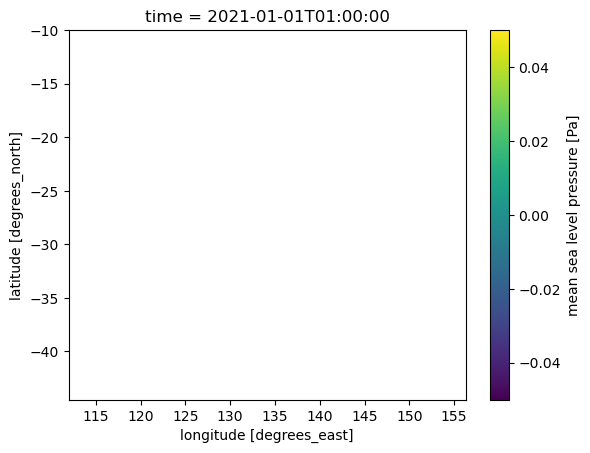

In [41]:
# Note - this plot will look quite strange! This is because of using a very simple merge 
# process which doesn't account for the different projections involved
pipe[doi].mslp[0].plot()
# xr.plot.contour(pipe[doi].surface_global_irradiance[0], levels=15, add_colorbar=True, )